<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/04_heart_disease_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/heart.csv', encoding='cp1252')
df.head()

Mounted at /content/drive


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.shape

(1025, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Data dictionary**

## Data Dictionary

- age: age in years
- sex: 1 = male, 0 = female
- cp: chest pain type (0-3): 0=typical angina, 1=atypical angina, 2=non-anginal pain, 3=asymptomatic
- trestbps: resting blood pressure (mm Hg)
- chol: serum cholesterol (mg/dl)
- fbs: fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
- restecg: resting ECG results (0-2)
- thalach: maximum heart rate achieved
- exang: exercise-induced angina (1 = yes, 0 = no)
- oldpeak: ST depression induced by exercise relative to rest
- slope: slope of peak exercise ST segment (0-2)
- ca: number of major vessels colored by fluoroscopy (0-4)
- thal: thalassemia (0-3, varies by dataset version)
- target: 1 = heart disease present, 0 = no heart disease

**2. Data Cleaning**

In [6]:
# Check missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
# Check duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()
df.shape

723


(302, 14)

In [8]:
# Check for illogical zero values in columns that shouldn't be zero
for col in ['chol', 'trestbps']:
    print(f"{col} == 0: {(df[col] == 0).sum()}")

chol == 0: 0
trestbps == 0: 0


In [10]:
# If any zeros found, treat as missing and impute with median
for col in ['chol', 'trestbps']:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        median_val = df[df[col] != 0][col].median()
        df[col] = df[col].replace(0, median_val)

df[['chol', 'trestbps']].describe()

,chol,trestbps
count,302.000000,302.000000
mean,246.500000,131.602649
std,51.753489,17.563394
min,126.000000,94.000000
25%,211.000000,120.000000
50%,240.500000,130.000000
75%,274.750000,140.000000
max,564.000000,200.000000


In [11]:
# Create readable label versions for plotting (keep originals for correlation/stats)
df['sex_label'] = df['sex'].map({1: 'Male', 0: 'Female'})
df['target_label'] = df['target'].map({1: 'Disease', 0: 'No Disease'})
df['cp_label'] = df['cp'].map({0: 'Typical Angina', 1: 'Atypical Angina',
                                  2: 'Non-anginal Pain', 3: 'Asymptomatic'})
df['exang_label'] = df['exang'].map({1: 'Yes', 0: 'No'})
df['fbs_label'] = df['fbs'].map({1: 'True', 0: 'False'})

df[['sex_label', 'target_label', 'cp_label', 'exang_label', 'fbs_label']].head()

,sex_label,target_label,cp_label,exang_label,fbs_label
0,Male,No Disease,Typical Angina,No,False
1,Male,No Disease,Typical Angina,Yes,True
2,Male,No Disease,Typical Angina,Yes,False
3,Male,No Disease,Typical Angina,No,False
4,Female,No Disease,Typical Angina,No,True


**3. Univariate Analysis**

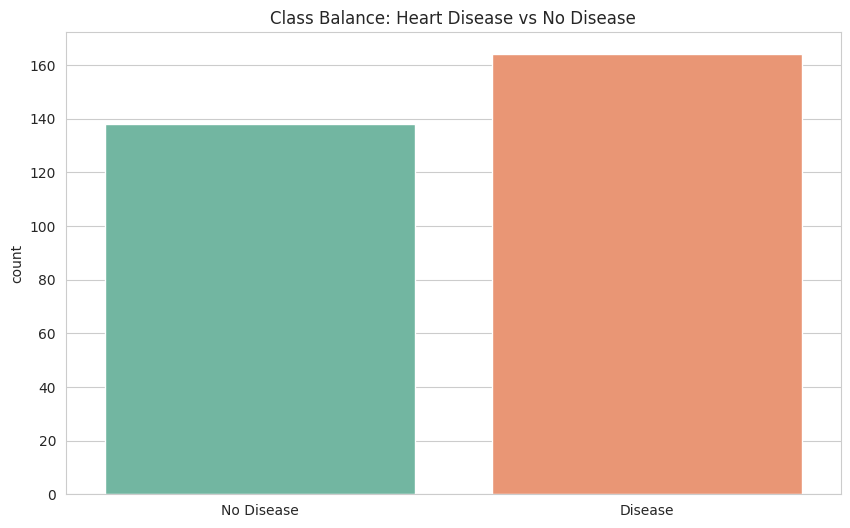

In [12]:
# Target class balance
sns.countplot(data=df, x='target_label', hue='target_label', palette='Set2', legend=False)
plt.title('Class Balance: Heart Disease vs No Disease')
plt.xlabel('')
plt.show()

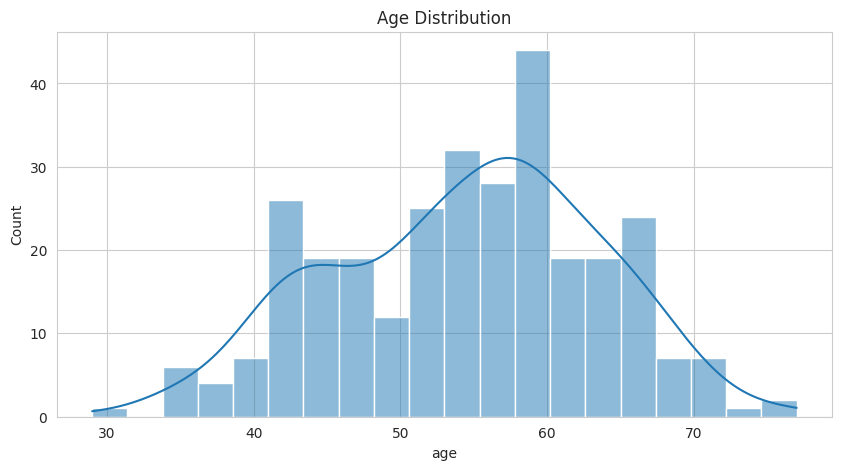

In [13]:
# Age distribution
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

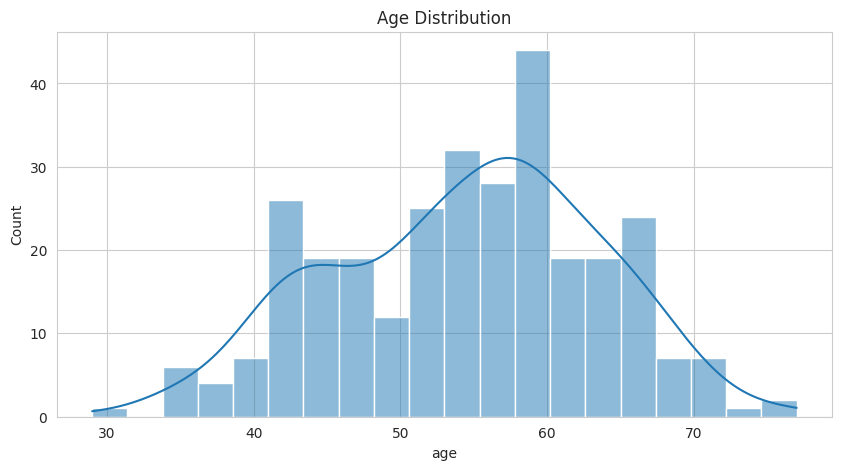

In [14]:
# Age distribution
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

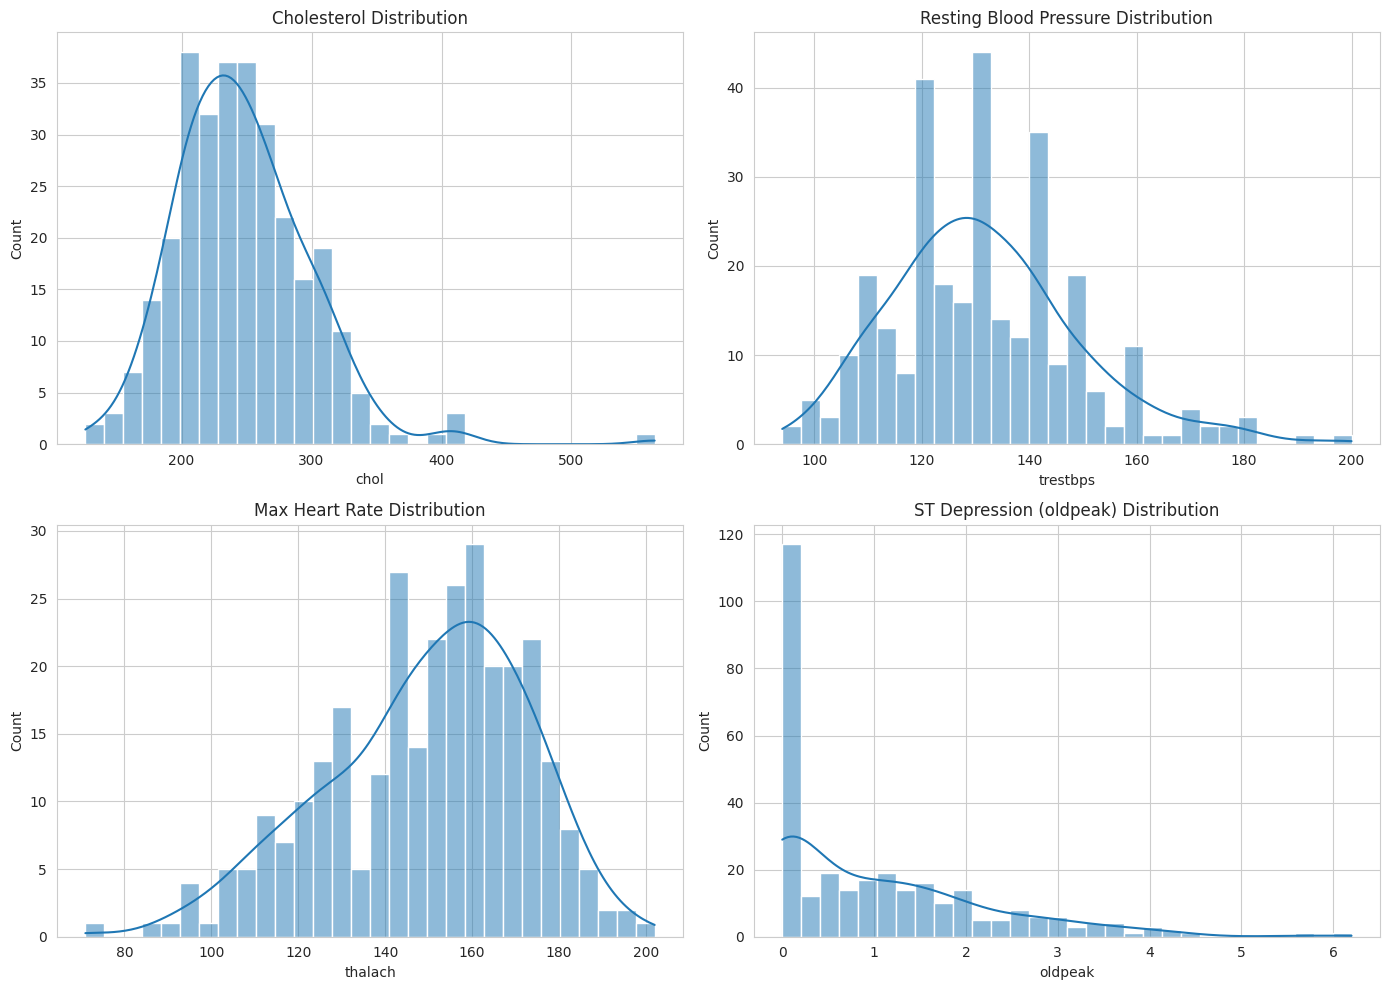

In [15]:
# Continuous features distributions
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(df['chol'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title('Cholesterol Distribution')

sns.histplot(df['trestbps'], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title('Resting Blood Pressure Distribution')

sns.histplot(df['thalach'], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title('Max Heart Rate Distribution')

sns.histplot(df['oldpeak'], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title('ST Depression (oldpeak) Distribution')

plt.tight_layout()
plt.show()

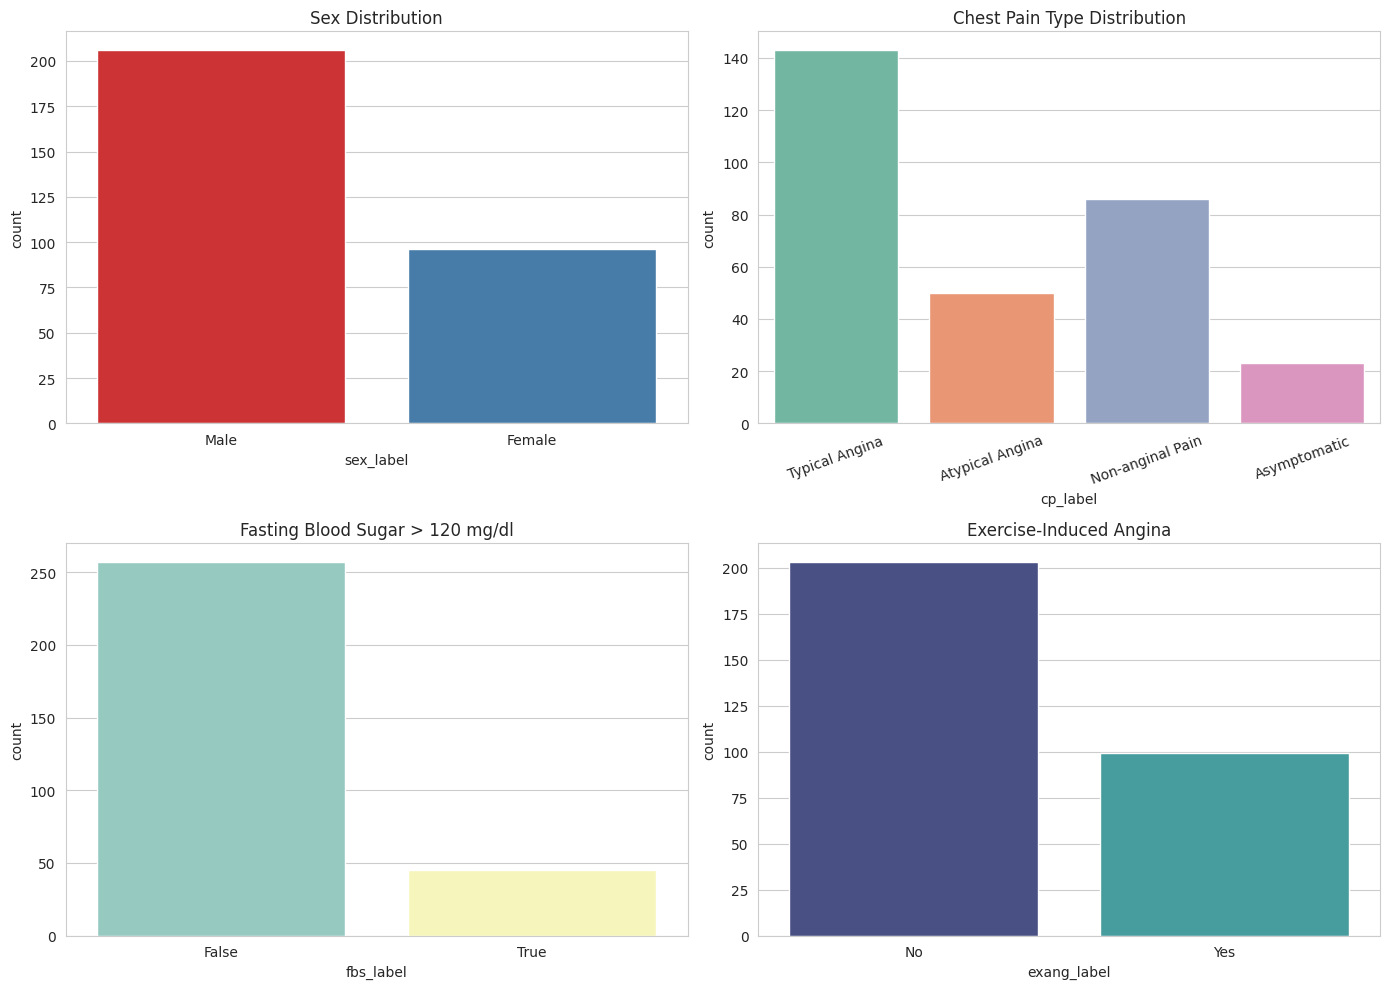

In [16]:
# Categorical features distributions
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(data=df, x='sex_label', hue='sex_label', palette='Set1', legend=False, ax=axes[0,0])
axes[0,0].set_title('Sex Distribution')

sns.countplot(data=df, x='cp_label', hue='cp_label', palette='Set2', legend=False, ax=axes[0,1])
axes[0,1].set_title('Chest Pain Type Distribution')
axes[0,1].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='fbs_label', hue='fbs_label', palette='Set3', legend=False, ax=axes[1,0])
axes[1,0].set_title('Fasting Blood Sugar > 120 mg/dl')

sns.countplot(data=df, x='exang_label', hue='exang_label', palette='mako', legend=False, ax=axes[1,1])
axes[1,1].set_title('Exercise-Induced Angina')

plt.tight_layout()
plt.show()

**4. Class-Based Comparison Analysis**

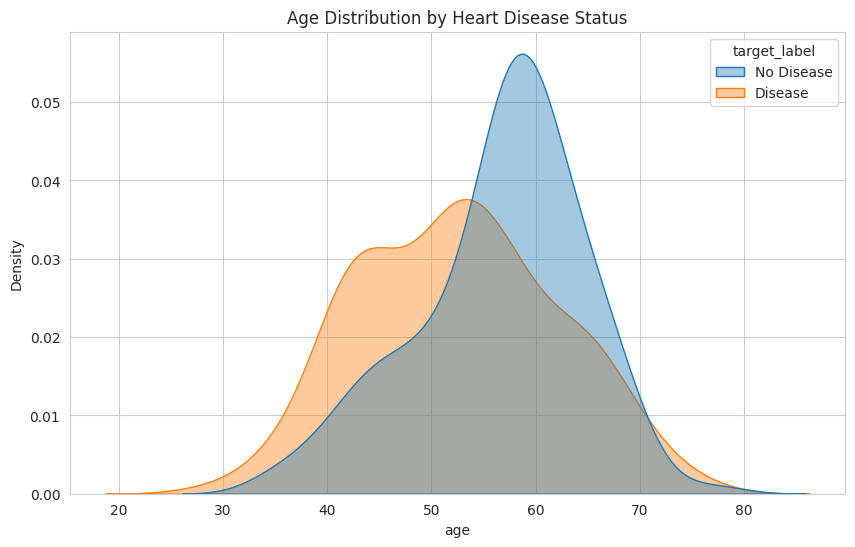

In [17]:
# Age by target
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='age', hue='target_label', fill=True, common_norm=False, alpha=0.4)
plt.title('Age Distribution by Heart Disease Status')
plt.show()

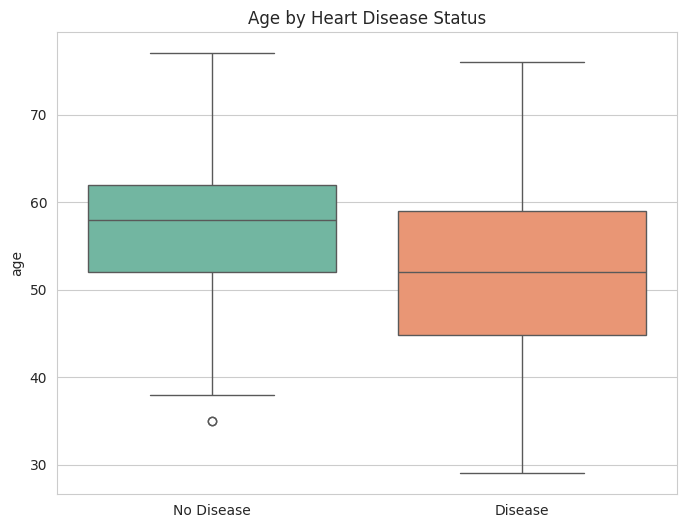

In [18]:
# Age by target - boxplot view
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='target_label', y='age', hue='target_label', palette='Set2', legend=False)
plt.title('Age by Heart Disease Status')
plt.xlabel('')
plt.show()

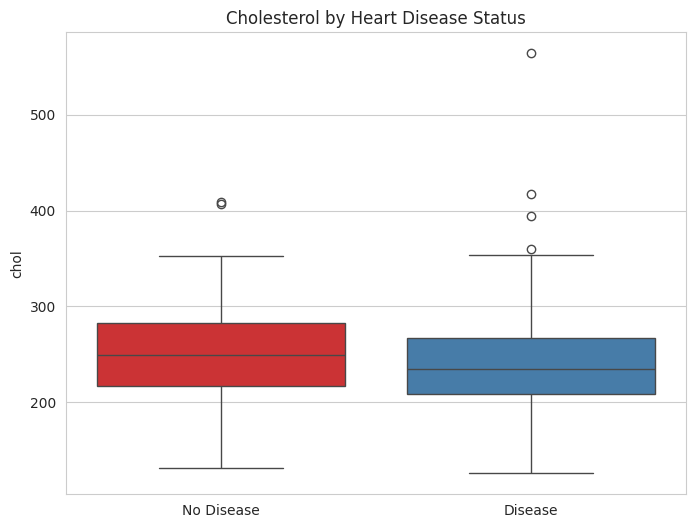

In [19]:
# Cholesterol by target
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='target_label', y='chol', hue='target_label', palette='Set1', legend=False)
plt.title('Cholesterol by Heart Disease Status')
plt.xlabel('')
plt.show()

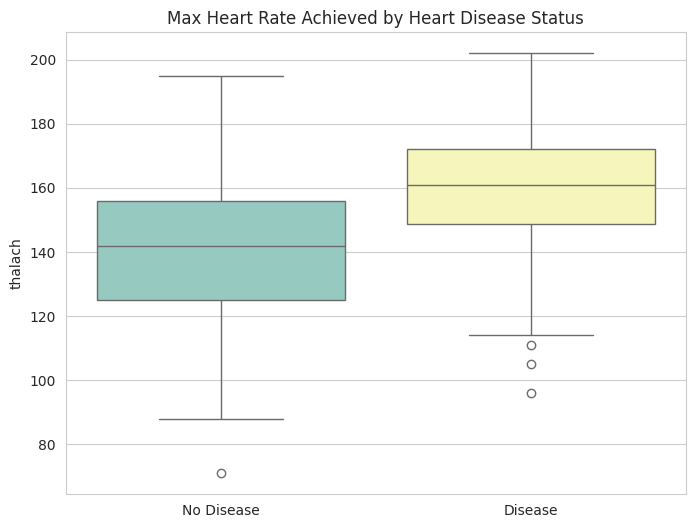

In [20]:
# Max heart rate by target
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='target_label', y='thalach', hue='target_label', palette='Set3', legend=False)
plt.title('Max Heart Rate Achieved by Heart Disease Status')
plt.xlabel('')
plt.show()

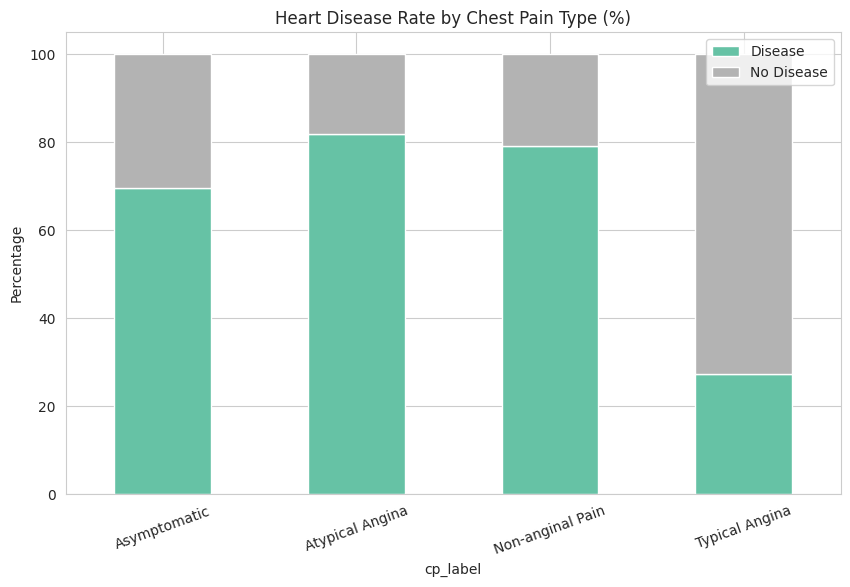

In [21]:
# Chest pain type vs target - proportion with disease per category
cp_target = pd.crosstab(df['cp_label'], df['target_label'], normalize='index') * 100

cp_target.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Heart Disease Rate by Chest Pain Type (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=20)
plt.legend(title='')
plt.show()

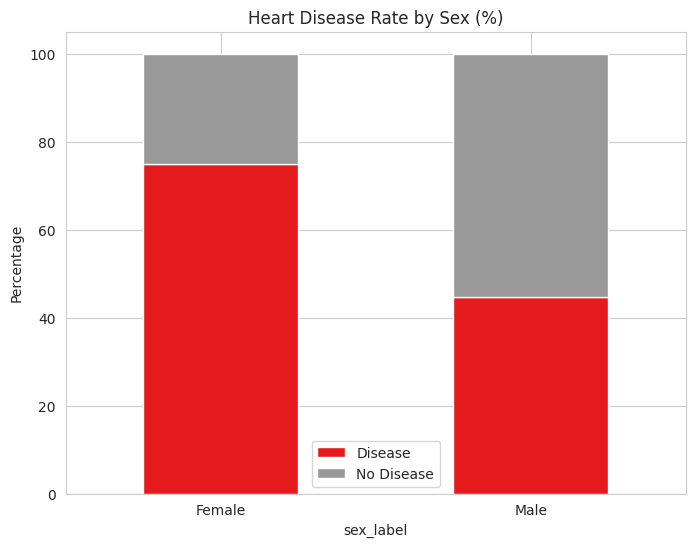

In [22]:
# Sex vs target
sex_target = pd.crosstab(df['sex_label'], df['target_label'], normalize='index') * 100

sex_target.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set1')
plt.title('Heart Disease Rate by Sex (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='')
plt.show()

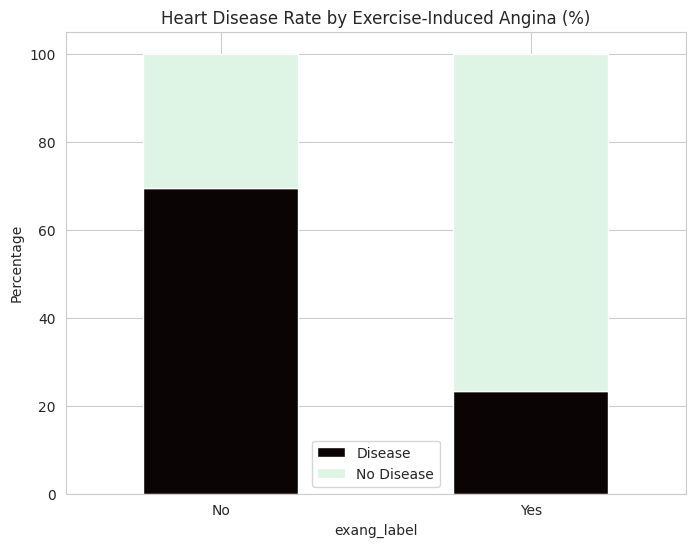

In [23]:
# Exercise-induced angina vs target
exang_target = pd.crosstab(df['exang_label'], df['target_label'], normalize='index') * 100

exang_target.plot(kind='bar', stacked=True, figsize=(8,6), colormap='mako')
plt.title('Heart Disease Rate by Exercise-Induced Angina (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='')
plt.show()

**5. Multivariate Analysis**

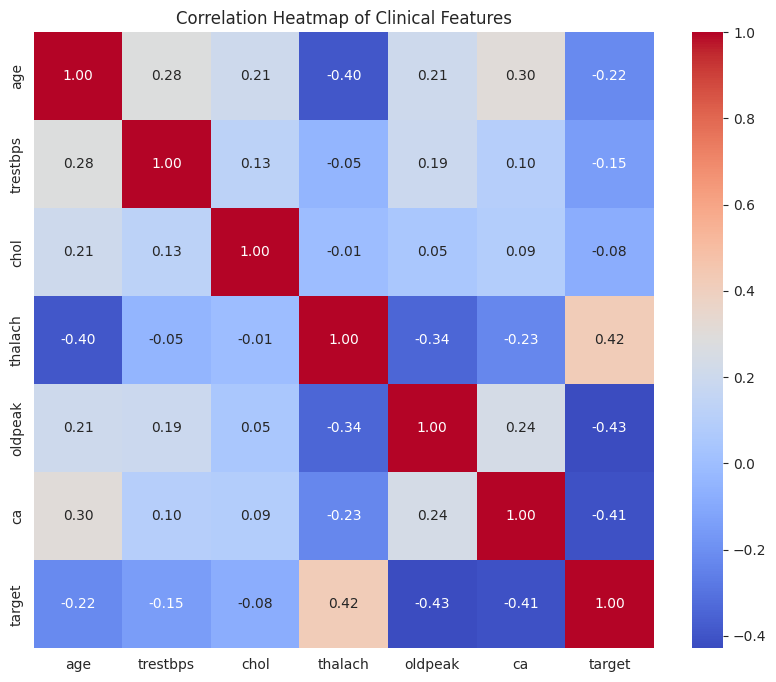

In [24]:
# Correlation heatmap - numeric columns only (use original numeric versions, not labels)
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'target']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Clinical Features')
plt.show()

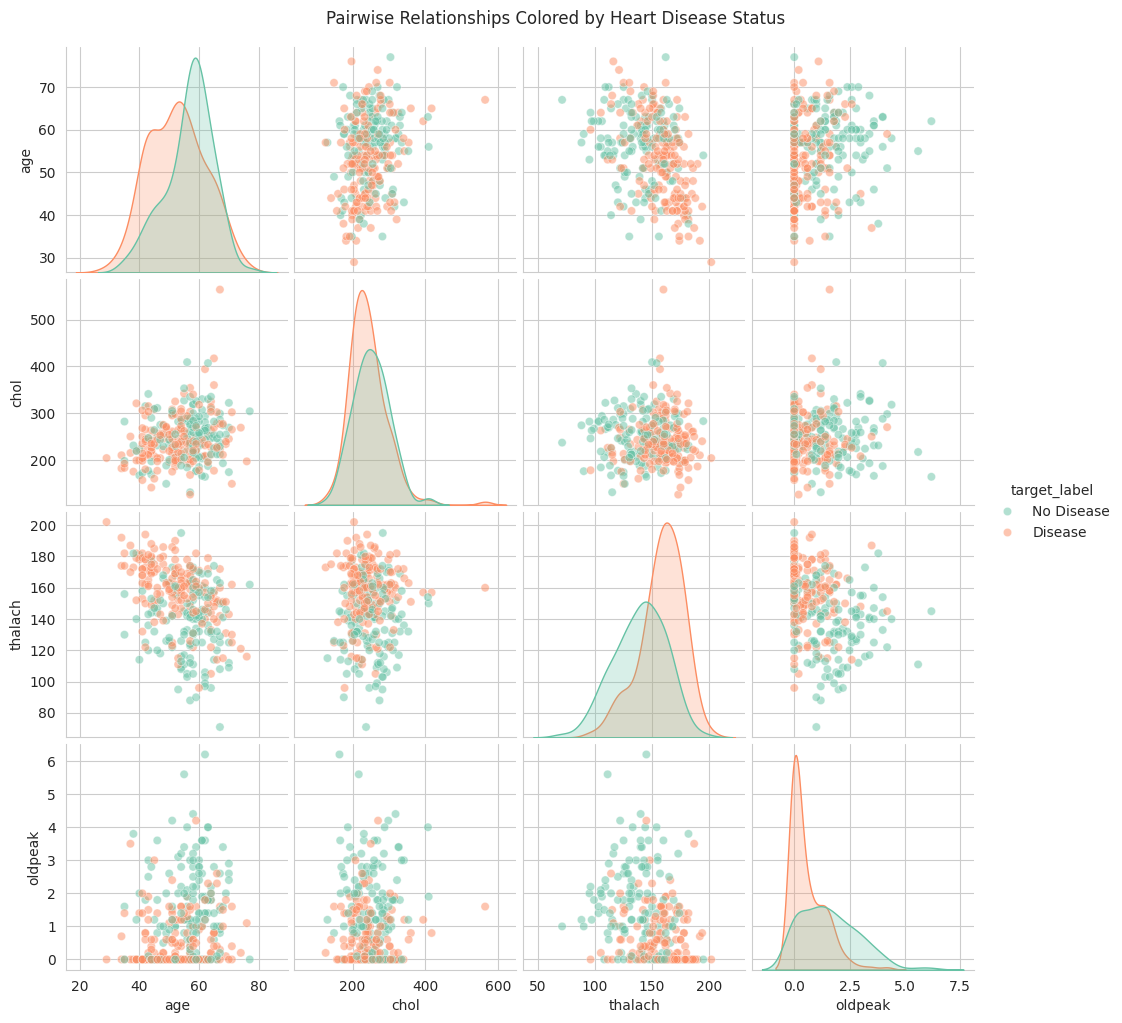

In [25]:
# Pairplot of key continuous features colored by target
sns.pairplot(df, vars=['age', 'chol', 'thalach', 'oldpeak'], hue='target_label',
             palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships Colored by Heart Disease Status', y=1.02)
plt.show()

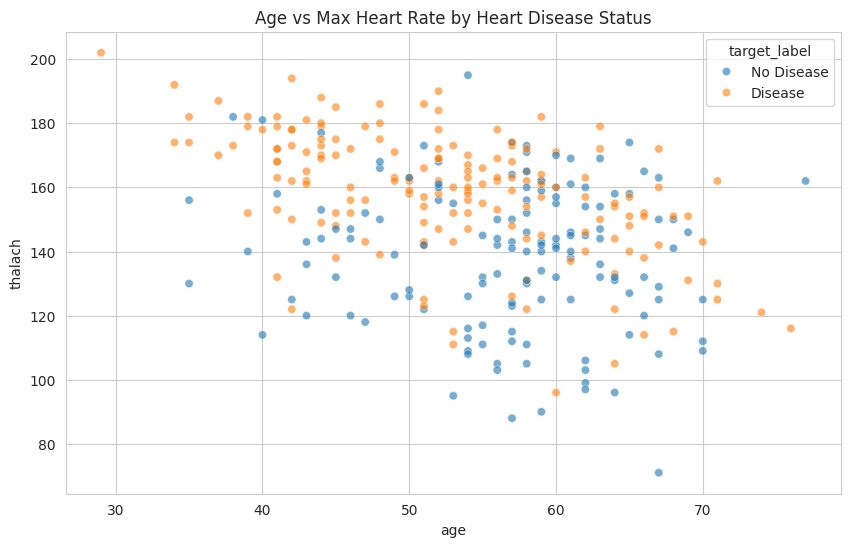

In [26]:
# Age vs max heart rate, colored by target
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='thalach', hue='target_label', alpha=0.6)
plt.title('Age vs Max Heart Rate by Heart Disease Status')
plt.show()

**6. Insights Summary**

## Key Insights

- Patients with heart disease in this dataset tend to have [lower/higher] max heart rate (thalach) — describe based on your boxplot.
- Age shows [some/little] separation between disease and no-disease groups — the KDE overlap suggests age alone isn't a strong standalone predictor.
- Chest pain type shows a clear pattern: [asymptomatic/typical angina] patients have a much higher rate of confirmed disease, which is counter-intuitive and worth noting.
- Exercise-induced angina is strongly associated with heart disease presence.
- Cholesterol shows [weaker than expected / notable] separation between groups — often surprising given its clinical reputation.
- The correlation heatmap shows [feature] has the strongest linear relationship with target, though correlation with a binary target has limits — logistic regression or point-biserial correlation would be a better next step.
- [Add 1-2 more insights specific to what you observed]

**Note:** This is an exploratory analysis, not a diagnostic tool. Findings describe patterns in this specific dataset and should not be interpreted as medical advice or causal relationships.